# Profiling a Filing Corpus Before You Index It

**Chapter 22: RAG for Financial Research**

## Purpose

Seven notebooks in this chapter retrieve over one corpus of annual reports.
Everything they can demonstrate is bounded by what that corpus contains, and
four of its properties change how an index should be built. None of the four
is visible from a row count.

The first is a timing property every financial document has: a 10-K describes a
fiscal year that ended weeks before the document became public, so the date to
filter on is not the date the report is about. The second is a keying property:
one company can reach the corpus under two ticker symbols, and a retriever
keyed on the symbol will return one document twice. The third is a coverage
property: a symbol-year that is absent produces no error at query time, only a
confident answer drawn from a different company's filing. The fourth is what
the stored text is: not the filing, and not its opening pages, but a window
the download chose by searching the document for one word.

## Learning objectives

After working through this notebook you will be able to:

- Read the shipped 10-K corpus with `data.load_sec_filings` and describe what
  it holds: how many filings, over which issuers, across what span of years.
- Measure the reporting lag between the fiscal period a filing covers and the
  date it became public, and say which of those two dates a point-in-time
  filter has to use.
- Find the documents that reach the corpus under more than one symbol, explain
  why the accession number rather than the ticker is a filing's identity, and
  say what an index keyed on the wrong one does at retrieval time.
- Identify the symbol-years the corpus does not cover, and explain why a
  missing document is more dangerous to a retrieval system than a malformed
  one.
- Establish from the text itself which window of each filing the corpus
  carries, and say what a topic-selected excerpt bounds in every retrieval
  result measured over it.
- State the trade-off between text-first and structure-aware parsing as a
  design contract, without attaching quality numbers no measurement supports.

## Book reference

Section 22.3, *Intelligent document ingestion*.

## Prerequisites

- The shipped 10-K corpus, read through `data.load_sec_filings`. It is
  downloaded by `data/equities/fundamentals/filings_download.py`; nothing here
  contacts the SEC, so no EDGAR identity is needed and the notebook produces
  the same values on every run.

## Setup

In [1]:
"""Profiling a filing corpus - timing, keys and coverage before an index is built."""

import warnings

import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display

# polars emits a repeating FutureWarning from its own deprecations and it says
# nothing about this run. Convergence, overflow and invalid-value warnings stay
# visible: they report conditions the results depend on.
warnings.filterwarnings("ignore", category=FutureWarning, module="polars")

import utils  # noqa: F401  - sets the Plotly renderer so figures carry a static PNG
from data import load_sec_filings
from utils.style import COLORS, show_plotly_with_alt

In [2]:
FORM_TYPE = "10-K"  # annual reports; the loader also serves 10-Q and 8-K
UNIVERSE = "sp100"  # the symbol universe the corpus was downloaded for
ANCHOR_TERM = "supplier"  # the word the download searches for to place the excerpt
ANCHOR_WINDOW_CHARS = 12_000  # width of the excerpt taken around the first occurrence
ANCHOR_LEAD_CHARS = 3_000  # characters of lead-in kept before the occurrence
FALLBACK_WINDOW_CHARS = 15_000  # width of the excerpt taken when there is no occurrence

## 1. What the corpus holds

The loader returns one row per filing, carrying the document text alongside
the metadata that identifies it. Nothing is fetched here: the corpus is on
disk, so the numbers below are the same on every run.

In [3]:
filings = load_sec_filings(FORM_TYPE, universe=UNIVERSE).sort("symbol", "filing_date")

display(
    Markdown(f"""
**{filings.height:,}** {FORM_TYPE} filings from **{filings["symbol"].n_unique()}** ticker
symbols, filed between {filings["filing_date"].min():%Y-%m-%d} and
{filings["filing_date"].max():%Y-%m-%d}. Every column is populated: the corpus carries no
nulls at all, in any field.

That last fact is worth stating precisely so it is not mistaken for a quality result. A
completeness check over this corpus passes by construction, and would pass whatever else was
wrong with it. The four sections that follow ask questions that can fail.
""")
)


**601** 10-K filings from **101** ticker
symbols, filed between 2020-01-21 and
2025-12-18. Every column is populated: the corpus carries no
nulls at all, in any field.

That last fact is worth stating precisely so it is not mistaken for a quality result. A
completeness check over this corpus passes by construction, and would pass whatever else was
wrong with it. The four sections that follow ask questions that can fail.


## 2. The date a filing is about is not the date you may use it

A 10-K reports on a fiscal year that has already ended. `period_end` is the
last day of that year; `filing_date` is the day the document reached EDGAR and
became public. Between them sits the time the company spent closing its books
and its auditors spent signing them off.

The distinction is the whole of point-in-time discipline for filings. A
backtest that joins a 10-K to the market on `period_end` is reading a document
that did not exist on that date, and the size of the error is the reporting
lag.

In [4]:
filings = filings.with_columns(
    (pl.col("filing_date") - pl.col("period_end")).dt.total_days().alias("reporting_lag_days")
)
lag = filings["reporting_lag_days"]
lag_min, lag_max, lag_median = int(lag.min()), int(lag.max()), float(lag.median())

display(
    Markdown(f"""
The reporting lag runs from **{lag_min}** to **{lag_max}** days, with a median of
**{lag_median:.0f}**. Not one filing in the corpus has a lag of zero or less, which is the
check that matters: a non-positive lag would mean a document dated before the period it
describes, and that is either a parsing error or a look-ahead waiting to happen.

Joining on `period_end` would therefore make every filing available a month and a half early,
on average, and almost two months early at the tail.
""")
)


The reporting lag runs from **18** to **62** days, with a median of
**47**. Not one filing in the corpus has a lag of zero or less, which is the
check that matters: a non-positive lag would mean a document dated before the period it
describes, and that is either a parsing error or a look-ahead waiting to happen.

Joining on `period_end` would therefore make every filing available a month and a half early,
on average, and almost two months early at the tail.


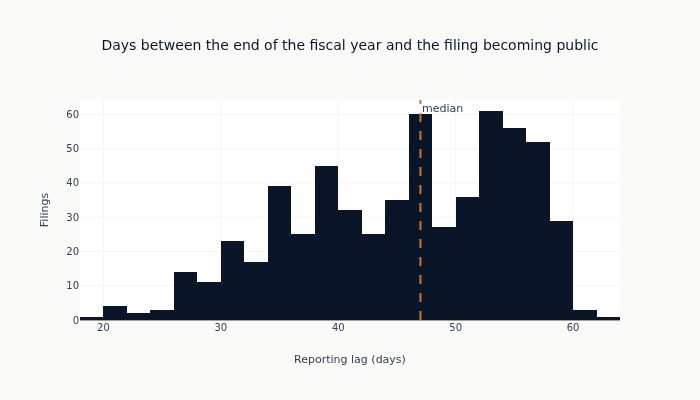

In [5]:
fig = go.Figure(
    go.Histogram(
        x=lag.to_list(),
        marker_color=COLORS["blue"],
        xbins=dict(start=0, end=int(lag.max()) + 5, size=2),
    )
)
fig.add_vline(
    x=lag_median,
    line=dict(color=COLORS["copper"], width=2, dash="dash"),
    annotation_text="median",
)
fig.update_layout(
    title="Days between the end of the fiscal year and the filing becoming public",
    xaxis_title="Reporting lag (days)",
    yaxis_title="Filings",
    height=400,
)
show_plotly_with_alt(
    fig,
    "A histogram of the reporting lag across the corpus, in two-day bins. The mass sits "
    "between roughly thirty and sixty days, with a dashed vertical line marking the median. "
    "No filing falls at or below zero.",
)

## 3. A filing's identity is its accession number, not its ticker

The SEC assigns every submission an **accession number**, unique across all
filers and all time. A ticker symbol is not unique in the same way: a company
with two share classes reaches a symbol universe under both, and the single
annual report it files arrives once for each.

In [6]:
by_accession = filings.group_by("accession_no").agg(
    pl.col("symbol").sort().alias("symbols"),
    pl.col("company_name").first().alias("company"),
    pl.len().alias("rows"),
)
shared = by_accession.filter(pl.col("rows") > 1).sort("company")
shared_rows = int(shared["rows"].sum())
distinct_documents = by_accession.height

display(
    Markdown(f"""
**{shared.height}** filings in the corpus arrive under more than one symbol, accounting for
**{shared_rows}** of the {filings.height:,} rows. Distinct documents:
**{distinct_documents:,}**.
""")
)
shared.select(
    pl.col("company").alias("Company"),
    pl.col("symbols").list.join(", ").alias("Symbols"),
    pl.col("accession_no").alias("Accession number"),
)


**6** filings in the corpus arrive under more than one symbol, accounting for
**12** of the 601 rows. Distinct documents:
**595**.


Company,Symbols,Accession number
str,str,str
"""Alphabet Inc.""","""GOOG, GOOGL""","""0001652044-20-000008"""
"""Alphabet Inc.""","""GOOG, GOOGL""","""0001652044-23-000016"""
"""Alphabet Inc.""","""GOOG, GOOGL""","""0001652044-21-000010"""
"""Alphabet Inc.""","""GOOG, GOOGL""","""0001652044-25-000014"""
"""Alphabet Inc.""","""GOOG, GOOGL""","""0001652044-24-000022"""
"""Alphabet Inc.""","""GOOG, GOOGL""","""0001652044-22-000019"""


### What that costs a retriever

Chunk the corpus row by row and each of these documents enters the index
twice. The duplicate is not detectable at query time by similarity, because
the two copies are identical: a retriever asked for the top five passages can
return the same passage twice and count it as two pieces of corroborating
evidence. An answer then cites two sources that are one source.

Deduplicating on `accession_no` before chunking removes it. Deduplicating on
`symbol` and `year` does not, because the two rows differ in exactly that
field.

## 4. What the corpus does not have

A retrieval system fails differently from a database. Ask a database for a row
it does not hold and it returns nothing; ask a retriever for a document it
does not hold and it returns the nearest thing it does hold, with a similarity
score that looks unremarkable. The absence has to be found before query time.

In [7]:
coverage = (
    filings.group_by("symbol")
    .agg(pl.col("year").n_unique().alias("years_covered"))
    .sort("years_covered", "symbol")
)
full_span = int(coverage["years_covered"].max())
partial = coverage.filter(pl.col("years_covered") < full_span)
per_year = filings.group_by("year").len().sort("year")

display(
    Markdown(f"""
All but **{partial.height}** of the symbols carry the full **{full_span}** years, and the
count of filings is flat across the span: {", ".join(f"{row['year']} at {row['len']}" for row in per_year.iter_rows(named=True))}.
The exception is
{", ".join(f"`{row['symbol']}`, which carries {row['years_covered']}" for row in partial.iter_rows(named=True))}.

Ask this corpus about that issuer's earlier annual reports and it answers from whichever
documents are nearest in embedding space. Nothing in the answer says the filing was absent,
and nothing in the similarity scores marks it out from an answer drawn from the right
document.
""")
)


All but **1** of the symbols carry the full **6** years, and the
count of filings is flat across the span: 2020 at 100, 2021 at 100, 2022 at 100, 2023 at 100, 2024 at 100, 2025 at 101.
The exception is
`BLK`, which carries 1.

Ask this corpus about that issuer's earlier annual reports and it answers from whichever
documents are nearest in embedding space. Nothing in the answer says the filing was absent,
and nothing in the similarity scores marks it out from an answer drawn from the right
document.


## 5. What the stored text is

The stored text is not a truncated filing. A real 10-K runs to hundreds of
thousands of characters, and the corpus stores one window per filing rather
than the document. `extract_10k_excerpt` in
`data/equities/fundamentals/filings_download.py` chooses the window by the
first of three rules that applies:

| Condition on the full filing | Window stored | Width |
|---|---|---|
| the word "supplier" occurs | from 3,000 characters before the first occurrence | 12,000 |
| no occurrence, filing longer than 35,000 characters | characters 20,000 through 35,000 | 15,000 |
| no occurrence, filing shorter than that | the opening | up to 15,000 |

Which rule fired is not recorded against the row. One of the three leaves a
signature in the text that survived it, and the other two do not - which is
itself worth measuring rather than assuming.

One measurement detail decides whether the check below works at all. Polars
`str.find` reports a **byte** offset, and this text carries typographic quotes
and currency signs, so a byte offset drifts past the character position it
should report wherever the preceding text is not pure ASCII, which is most of
these filings. The download slices Python strings, which count
characters, so the check measures the character length of the text that
precedes the first occurrence.

In [8]:
lowered = pl.col("text").str.to_lowercase()
filings = filings.with_columns(
    pl.when(lowered.str.contains(ANCHOR_TERM, literal=True))
    .then(lowered.str.split(ANCHOR_TERM).list.first().str.len_chars())
    .otherwise(None)
    .alias("anchor_offset")
)
anchored = filings.filter(pl.col("anchor_offset").is_not_null())
unanchored = filings.filter(pl.col("anchor_offset").is_null())
fallback = unanchored.filter(pl.col("text_length") == FALLBACK_WINDOW_CHARS)
opening = unanchored.filter(pl.col("text_length") != FALLBACK_WINDOW_CHARS)
at_lead = anchored.filter(pl.col("anchor_offset") == ANCHOR_LEAD_CHARS).height
before_lead = anchored.filter(pl.col("anchor_offset") < ANCHOR_LEAD_CHARS).height
after_lead = anchored.filter(pl.col("anchor_offset") > ANCHOR_LEAD_CHARS).height
anchored_share = anchored.height / filings.height

display(
    Markdown(f"""
**{anchored.height}** of the {filings.height:,} excerpts contain the word "{ANCHOR_TERM}", and
where it sits is not incidental. In **{at_lead}** of them the first occurrence is at character
{ANCHOR_LEAD_CHARS:,} exactly - the lead-in the download keeps. In the other {before_lead} it
comes earlier, which is what happens when the filing's own first occurrence falls inside the
first {ANCHOR_LEAD_CHARS:,} characters and the window has nowhere to start but the beginning.

**{after_lead}** sit later than character {ANCHOR_LEAD_CHARS:,}, and that is the number that
can fail: any excerpt above it would be one the window was not placed on.

So for **{anchored_share:.0%}** of this corpus the stored text is the filing's discussion of
its suppliers and the pages around it. Not the annual report, and not its opening pages.
""")
)


**549** of the 601 excerpts contain the word "supplier", and
where it sits is not incidental. In **544** of them the first occurrence is at character
3,000 exactly - the lead-in the download keeps. In the other 5 it
comes earlier, which is what happens when the filing's own first occurrence falls inside the
first 3,000 characters and the window has nowhere to start but the beginning.

**0** sit later than character 3,000, and that is the number that
can fail: any excerpt above it would be one the window was not placed on.

So for **91%** of this corpus the stored text is the filing's discussion of
its suppliers and the pages around it. Not the annual report, and not its opening pages.


### The other two rules cannot be told apart

In [9]:
display(
    Markdown(f"""
The remaining **{filings.height - anchored.height}** excerpts contain no occurrence of
"{ANCHOR_TERM}" anywhere. **{fallback.height}** of them are exactly
{FALLBACK_WINDOW_CHARS:,} characters long and **{opening.height}** are shorter.

Which rule produced the {FALLBACK_WINDOW_CHARS:,}-character group cannot be established from
this corpus. That length is what the mid-document rule always returns, and it is also what
the opening rule returns for any filing between {FALLBACK_WINDOW_CHARS:,} and 35,000
characters. Telling them apart needs the full filing, and the corpus stores the excerpt
instead.

Name that rather than work around it. A pipeline that transforms a document should record the
transform: one column holding which rule fired would turn this from an inference into a
lookup, and would let a retrieval system downstream tell a supplier passage from a slice taken
out of the middle of a document. Nothing in the stored corpus carries that column.
""")
)


The remaining **52** excerpts contain no occurrence of
"supplier" anywhere. **45** of them are exactly
15,000 characters long and **7** are shorter.

Which rule produced the 15,000-character group cannot be established from
this corpus. That length is what the mid-document rule always returns, and it is also what
the opening rule returns for any filing between 15,000 and 35,000
characters. Telling them apart needs the full filing, and the corpus stores the excerpt
instead.

Name that rather than work around it. A pipeline that transforms a document should record the
transform: one column holding which rule fired would turn this from an inference into a
lookup, and would let a retrieval system downstream tell a supplier passage from a slice taken
out of the middle of a document. Nothing in the stored corpus carries that column.


### What a topic-selected corpus bounds

Every chunking, embedding and retrieval result later in the chapter is
computed over this material. The comparisons stay valid as comparisons,
because each one runs the alternatives over the same text - but what they
compare is retrieval over procurement and supply-chain prose, not retrieval
over annual reports.

Two consequences follow for reading the numbers downstream. A retriever that
does well here has done well on one topic, so a domain embedding model's
margin over a general-purpose one is a margin on that topic and does not
transfer to a corpus about, say, revenue recognition. And a question this
corpus cannot answer is not always a coverage hole in the sense of section 4:
the filing may well be present and simply have been cut somewhere else.

The selection is not accidental. `23_knowledge_graphs/02_supply_chain_kg_construction`
reads this same corpus through the same loader call and extracts supplier,
customer and competitor relationships from it, which is work the anchored
window puts the text in front of.

## 6. The parser-mode contract

Metadata decides which documents an index may serve. How each document is
broken into retrievable units is the next decision, and two strategies bound
the space:

- **Text-first** parsing strips structure and emits a single character stream.
  Fast and uniform, but tables fragment, headings detach from their sections,
  and chunking has nothing structural to anchor to.
- **Structure-aware** parsing preserves tables, headings and list hierarchy.
  Slower per page, but chunking can respect semantic units and a citation can
  resolve to a section rather than to a character offset.

| Parser mode | Preserves | Primary risk |
|---|---|---|
| Text-first | Linear prose | Tables and section hierarchy may be lost |
| Structure-aware | Prose, tables, headings, lists | More extraction complexity |

This notebook attaches no quality or latency number to either mode, because it
measures neither. A comparison that could support one needs a labelled sample
of prose, tables, headings and footnotes, and a runtime measured on the same
documents.

## 7. Key takeaways

In [10]:
display(
    Markdown(f"""
**Filter on the date the document became public.** Every filing here describes a fiscal year
that ended {lag_min} to {lag_max} days before it was published. `period_end` is a
property of the subject matter and `filing_date` is a property of the information set; only
the second one bounds what a decision could have used.

**Key documents by what the publisher made unique.** {shared.height} annual reports in this
corpus arrive under two ticker symbols each, because a dual-class company belongs to the
universe twice. The accession number identifies the submission; the ticker identifies a
listing, and a listing is not a document. An index keyed on the ticker holds those reports
twice and can cite one document as two sources.

**Look for what is missing before you query, not after.** A retriever has no way to answer
"there is no such filing". It returns the nearest documents it holds and scores them
normally, so a coverage hole surfaces as a confident, wrong answer rather than as an error.
The check is a group-by, and it costs nothing next to the cost of not doing it.

**Know what the corpus is an extract of, and what chose the extract.** For
{anchored_share:.0%} of these documents the stored text is a window of at most
{ANCHOR_WINDOW_CHARS:,} characters, taken from {ANCHOR_LEAD_CHARS:,} characters before the
filing's first mention of suppliers, so every
retrieval result later in the chapter is measured over supply-chain prose rather than over
annual reports. That does not invalidate the comparisons, which all run on the same text - it
says what they are comparisons of.

### Known limitations

- The corpus is a fixed download rather than a live feed. It cannot show a filing being
  amended, restated or withdrawn, and a production ingestion pipeline has to handle all
  three.
- `filing_date` is day-level. The SEC records an acceptance timestamp to the second, and a
  strategy acting on the day of a filing needs it: a document accepted after the close was
  not available to trade on that day.
- Coverage is measured in filings per symbol-year. It says nothing about whether the text of
  any particular filing extracted cleanly, which is a question about the parser rather than
  about the corpus.
- The excerpt rule is fixed at download time and cannot be varied here. Measuring how much of
  a retrieval result comes from the topic selection rather than from the retriever would need
  a second corpus cut on a different anchor, which this repository does not ship.

**Next**: [`02_domain_embeddings_comparison`](02_domain_embeddings_comparison.ipynb) embeds
this corpus and asks whether a finance-specific model retrieves it better than a
general-purpose one.
""")
)


**Filter on the date the document became public.** Every filing here describes a fiscal year
that ended 18 to 62 days before it was published. `period_end` is a
property of the subject matter and `filing_date` is a property of the information set; only
the second one bounds what a decision could have used.

**Key documents by what the publisher made unique.** 6 annual reports in this
corpus arrive under two ticker symbols each, because a dual-class company belongs to the
universe twice. The accession number identifies the submission; the ticker identifies a
listing, and a listing is not a document. An index keyed on the ticker holds those reports
twice and can cite one document as two sources.

**Look for what is missing before you query, not after.** A retriever has no way to answer
"there is no such filing". It returns the nearest documents it holds and scores them
normally, so a coverage hole surfaces as a confident, wrong answer rather than as an error.
The check is a group-by, and it costs nothing next to the cost of not doing it.

**Know what the corpus is an extract of, and what chose the extract.** For
91% of these documents the stored text is a window of at most
12,000 characters, taken from 3,000 characters before the
filing's first mention of suppliers, so every
retrieval result later in the chapter is measured over supply-chain prose rather than over
annual reports. That does not invalidate the comparisons, which all run on the same text - it
says what they are comparisons of.

### Known limitations

- The corpus is a fixed download rather than a live feed. It cannot show a filing being
  amended, restated or withdrawn, and a production ingestion pipeline has to handle all
  three.
- `filing_date` is day-level. The SEC records an acceptance timestamp to the second, and a
  strategy acting on the day of a filing needs it: a document accepted after the close was
  not available to trade on that day.
- Coverage is measured in filings per symbol-year. It says nothing about whether the text of
  any particular filing extracted cleanly, which is a question about the parser rather than
  about the corpus.
- The excerpt rule is fixed at download time and cannot be varied here. Measuring how much of
  a retrieval result comes from the topic selection rather than from the retriever would need
  a second corpus cut on a different anchor, which this repository does not ship.

**Next**: [`02_domain_embeddings_comparison`](02_domain_embeddings_comparison.ipynb) embeds
this corpus and asks whether a finance-specific model retrieves it better than a
general-purpose one.
